## Similarity evaluation with Frechet distance  
We compare MovingPandas and MobilityPandas (which uses PyMEOS) libraries.
We calculate Frechet distance between a trajectory and the following one in the dataset.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
from shapely import frechet_distance, LineString

from geopandas import GeoDataFrame
import zipfile

import sys
sys.path.append("..")

import warnings
import numpy as np
warnings.simplefilter("ignore")
from pyproj import Transformer

import pymeos
from pymeos import TGeomPointSeq

pymeos.pymeos_initialize()

We use AIS data.

In [2]:
zip_path = 'data/aisdk-2025-07-11.zip'
csv_filename = 'aisdk-2025-07-11.csv'

sizes = {'small': 100000, 'medium': 1000000, 'large': 4000000}
chosen_size = 'large'

In [3]:
def extraction():
    global df
    with zipfile.ZipFile(zip_path) as archive:        
        with archive.open(csv_filename) as file:
            df = pd.read_csv(file, usecols=['# Timestamp', 'MMSI', 'Latitude', 'Longitude'], nrows=sizes[chosen_size])

    df.rename(columns={'# Timestamp': 't', 'MMSI': 'mmsi', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
    df = df[df['lat'] <= 90] # default latitude = 91°
    df = df.sort_values(['mmsi', 't'])
    df = df.drop_duplicates(subset=['mmsi', 't'], keep='last')

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

    df[['x', 'y']] = df.apply(
        lambda row: pd.Series(transformer.transform(row['lon'], row['lat'])),
        axis=1
    )
    df = df.drop(columns=['lat', 'lon'])

    global nb_points
    nb_points = df.shape[0]

# extraction()

## MovingPandas (without PyMEOS)

In [4]:
def construction_without():
    df1 = df.copy()
    df1['geometry'] = [Point(x, y) for x, y in zip(df1['x'], df1['y'])]
    gdf = GeoDataFrame(df1, geometry='geometry')
    gdf.set_crs(epsg=25832, inplace=True)
    gdf['t'] = pd.to_datetime(gdf['t'])

    global trajectories_without
    trajectories_without = gdf

# construction_without()

## MobilityPandas (with PyMEOS)
We use `from_arrays` method.

In [5]:
def construction_with():

    df3 = df.copy()
    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_with
    tr = (df3.groupby('mmsi')
        .apply(lambda traj: TGeomPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['x'].values, 
            y = traj['y'].values,
            srid = 25832,
            upper_inc=True,
        ))
        .rename('trajectory')
    ).to_frame()

    trajectories_with = tr['trajectory'].apply(
        lambda seq: TGeomPointSeq.from_instants(seq.instants(), upper_inc=True)
    ).to_frame(name='trajectory')

    trajectories_with = trajectories_with[trajectories_with['trajectory'].apply(lambda t: t.num_instants() > 1)]

# construction_with()

## Calculation

In [6]:
def calc_with():
    global distances_with

    distances_with = []

    for i in range(len(trajectories_with.index)-1):
        t1 = trajectories_with.trajectory[trajectories_with.index[i]]
        t2 = trajectories_with.trajectory[trajectories_with.index[i+1]]
        distances_with.append(t1.frechet_distance(t2))    

# calc_with()

In [ ]:
def calc_without():

    global distances_without
    grouped = trajectories_without.groupby('mmsi')
    grouped = {mmsi: group for mmsi, group in grouped if len(group) >= 2}

    trajectories = []
    for _, group in grouped.items():
        group_sorted = group.sort_values('t')
        line = LineString(group_sorted['geometry'].tolist())
        trajectories.append(line)

    distances_without = [
        frechet_distance(trajectories[i], trajectories[i + 1])
        for i in range(len(trajectories) - 1)
    ]

# calc_without()

## Measures

In [8]:
import time
from memory_profiler import memory_usage
results = {}

def mem_and_cpu_time(f, n=4):

    mem_usage = memory_usage((f), interval=0.01)
    mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    times.pop(times.index(max(times)))
    times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    results[f.__name__] = (mean_t, mem_used)
    # results[f.__name__] = (mean_t, 0)  # if you don't want to calculate memory usage


    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    print(f"Memory usage : {mem_used:.2f} MiB\n")


extraction()
construction_with()
mem_and_cpu_time(construction_without)
mem_and_cpu_time(calc_without)
mem_and_cpu_time(calc_with)

Function construction_without:
CPU time over 4 runs: 10.048052 sec ± 0.174500 sec
Memory usage : 329.44 MiB

Function calc_without:
CPU time over 4 runs: 51.326499 sec ± 0.069265 sec
Memory usage : 377.62 MiB

Function calc_with:
CPU time over 4 runs: 9.043009 sec ± 0.004175 sec
Memory usage : 0.00 MiB



In [9]:
# extraction()
# construction_without()
# construction_with()
# simplify_without()
# simplify_with()

add data from the construction benchmark

In [10]:
if chosen_size == 'small':
    results['extraction'] = (3.907518819249997, 112.05859375)
    # results['construction_without'] = (3.0670779807500033, 2.25)
    results['construction_with'] = (1.1410889672500026, 1.0)

elif chosen_size == 'medium':
    results['extraction'] = (36.63349021150001, 1043.78515625)
    # results['construction_without'] = (8.769085886750005, 67.4765625)
    results['construction_with'] = (3.2806865339999973, 0.0)

elif chosen_size == 'large':
    results['extraction'] = (164.43046756125, 5062.60546875)
    # results['construction_without'] = (20.915836654249972, 433.7890625)
    results['construction_with'] = (10.292904473250076, 2.0)

else:
    raise Exception("Chosen size must be small, medium or large")


# Performance measures

## Time and memory

### Calculation

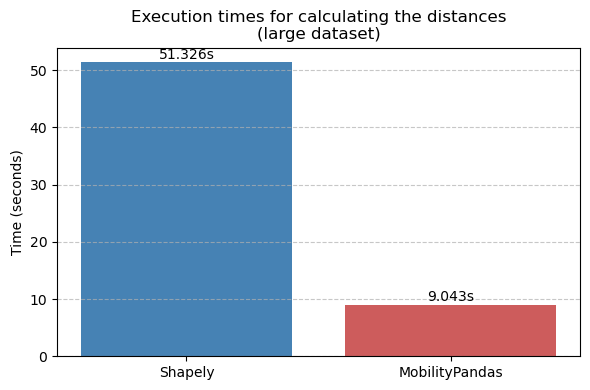

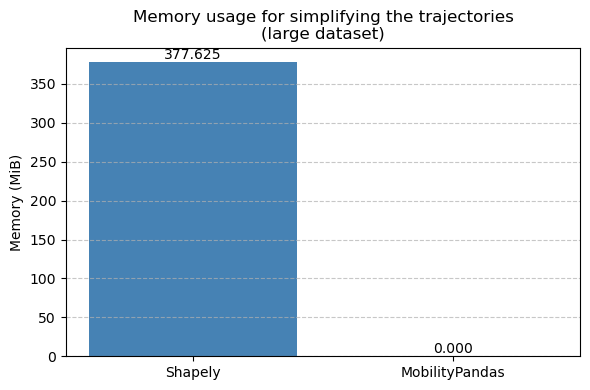

In [ ]:
timesCa = [results['calc_without'][0], results['calc_with'][0]]
memCa = [results['calc_without'][1], results['calc_with'][1]]
libs = ['Shapely', 'MobilityPandas']

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, timesCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for calculating the distances\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, memCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for calculating the distances\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Complete process

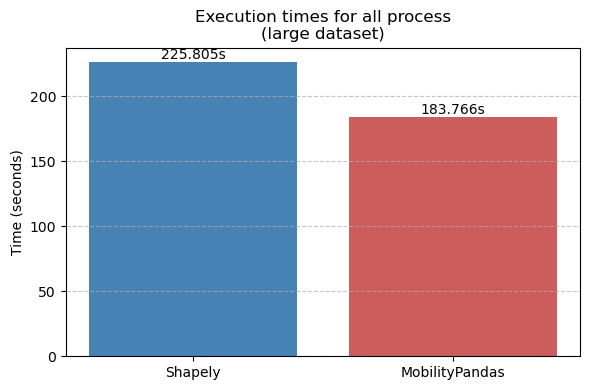

In [12]:
times = [results['extraction'][0] + results['construction_without'][0] + results['calc_without'][0], 
         results['extraction'][0]+ results['construction_with'][0] + results['calc_with'][0]]

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, times, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for all process\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

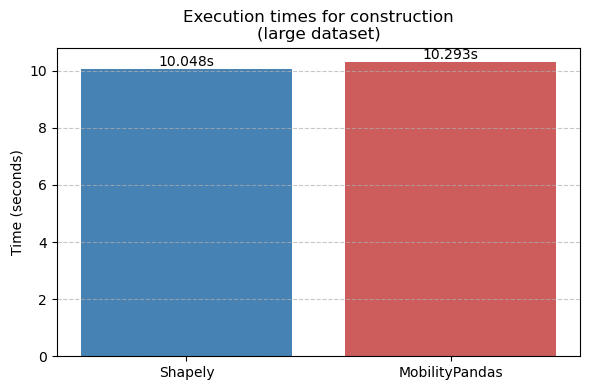

In [13]:
timesCo = [results['construction_without'][0], results['construction_with'][0]]

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, timesCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for construction\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Check that the results are the same

In [14]:
d_with, d_without = np.round(np.array(distances_with), 2), np.round(np.array(distances_without), 2)
print(list(d_with) == list(d_without))

for i in range(len(d_with)):
    if d_with[i] != d_without[i]:
        print(i)
        print('MobilityPandas: ', d_without[i], 'MovingPandas: ', d_with[i], '\n')


True
